# Activity 1 Diagnose & Clean
### Day 2: Data Cleaning & Preparation (SDA Data Science Bootcamp)

**Time:** ~30 minutes
**Dataset:** Melbourne Housing Snapshot (real listings data, ~23,500 rows)
**Maps to:** Handling Missing Values, Detecting & Treating Outliers

---
### What you'll practice
1. Auditing a dataset for missing values and duplicates
2. Deciding *drop vs. impute* using a defensible rule of thumb
3. Detecting outliers visually and with the IQR rule
4. Treating outliers with capping (Winsorization)

> This is the **same dataset family** behind real automated valuation failures (recall the Zillow case study from lecture). Getting this step wrong has real financial consequences not just academic ones.

Cells marked **`# TODO`** are for you to complete. A **Solution** cell follows each one if you get stuck try first before peeking!


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
sns.set_style("whitegrid")
print("Libraries loaded.")


Libraries loaded.


## 2. Load the Data

We're loading a real, messy snapshot of Melbourne, Australia housing listings directly from a public GitHub source no download/upload needed.

In [17]:
DATA_URL = "https://raw.githubusercontent.com/prakharp7/Data-Cleaning-Melbourne-Housing-Dataset/main/Melbourne.csv"
df = pd.read_csv(DATA_URL)
print(df.shape)
df.head()


(23547, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,03-09-2016,2.5,3067.0,2.0,1.0,1.0,126.0,NaN,NaN,Yarra,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,03-12-2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,04-02-2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,04-02-2016,2.5,3067.0,3.0,2.0,1.0,0.0,NaN,NaN,Yarra,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,04-03-2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## 3. First Look

Before touching anything, get an inventory of what you're working with.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23547 entries, 0 to 23546
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         23547 non-null  object 
 1   Address        23547 non-null  object 
 2   Rooms          23547 non-null  int64  
 3   Type           23547 non-null  object 
 4   Price          18396 non-null  float64
 5   Method         23547 non-null  object 
 6   SellerG        23547 non-null  object 
 7   Date           23547 non-null  object 
 8   Distance       23546 non-null  float64
 9   Postcode       23546 non-null  float64
 10  Bedroom2       19066 non-null  float64
 11  Bathroom       19063 non-null  float64
 12  Car            18921 non-null  float64
 13  Landsize       17410 non-null  float64
 14  BuildingArea   10018 non-null  float64
 15  YearBuilt      11540 non-null  float64
 16  CouncilArea    15656 non-null  object 
 17  Lattitude      19243 non-null  float64
 18  Longti

## 4. Missing Value Audit

Run the cell below to see how much data is missing per column, both in raw counts and as a percentage.

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0]
missing_report


,missing_count,missing_pct
BuildingArea,13529,57.5
YearBuilt,12007,51.0
CouncilArea,7891,33.5
Landsize,6137,26.1
Price,5151,21.9
Car,4626,19.6
Bathroom,4484,19.0
Bedroom2,4481,19.0
Lattitude,4304,18.3
Longtitude,4304,18.3


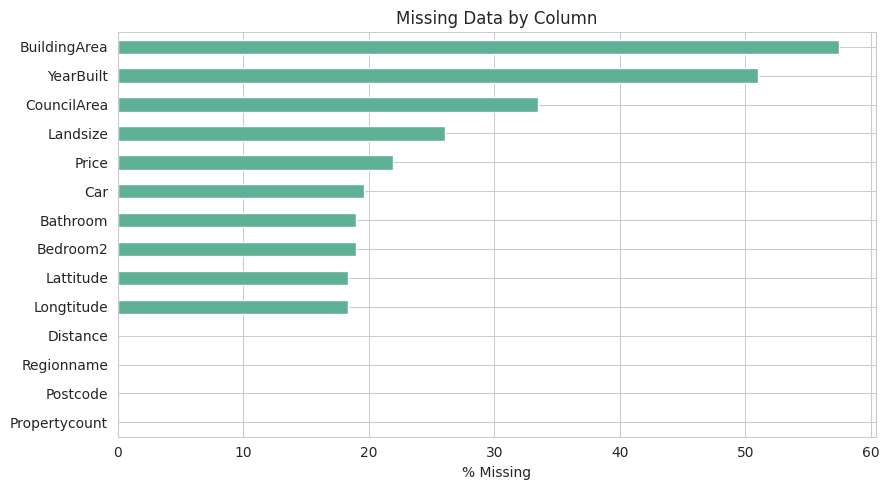

In [5]:
# Visualize it
plt.figure(figsize=(9, 5))
missing_report["missing_pct"].plot(kind="barh", color="#5EB096")
plt.xlabel("% Missing")
plt.title("Missing Data by Column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Decision point

Recall the rule of thumb from lecture:
- **< 5% missing** → safe to drop the affected rows
- **> 50% missing** → consider dropping the column entirely (too sparse to trust)
- **Everything in between** → impute

Look at the report above. Which columns fall into which bucket?

**`# TODO`** Fill in the blanks below.

In [8]:
# TODO: Based on the missing_report above, list the columns that are >50% missing

# I drop columns with >50% missing data (like BuildingArea and YearBuilt)
# because too much missing info introduces noise and reduces model reliability
high_missing_cols = ["BuildingArea", "YearBuilt"]

# TODO: List columns that are missing but under 50% (candidates to impute, not drop)

#  I keep and impute columns with <50% missing data (like Price, Car, Bathroom, etc.)
# because dropping them would result in losing valuable information, and imputation safely fills the gaps
impute_cols = ["Price", "Car", "Bathroom", "Bedroom2", "Landsize", "CouncilArea"]

print("Drop candidates:", high_missing_cols)
print("Impute candidates:", impute_cols)


Drop candidates: ['BuildingArea', 'YearBuilt']
Impute candidates: ['Price', 'Car', 'Bathroom', 'Bedroom2', 'Landsize', 'CouncilArea']


<details>
<summary>Solution (click to expand)</summary>

```python
high_missing_cols = ["BuildingArea", "YearBuilt", "CouncilArea"]
impute_cols = ["Price", "Car", "Bathroom", "Bedroom2", "Landsize", "Lattitude", "Longtitude"]
```

**Why:** `BuildingArea` (57%), `YearBuilt` (51%), and `CouncilArea` (33%) are missing enough of the time that any imputation would be mostly guesswork. `Price` is our likely target for a future model, and the rest including `Lattitude`/`Longtitude` (~18% missing each) are numeric fields missing in a minority of rows: good imputation candidates.

Note: `Price` missing is a special case for a *supervised* task you'd usually drop rows with missing target rather than impute it (you can't train on a guessed label). We'll do that in Activity 2.

A few other columns (`Distance`, `Postcode`, `Regionname`, `Propertycount`) are missing exactly 1 row too small to matter either way; a final `dropna()` sweep after the targeted imputation below clears these quietly.
</details>


## 5. Duplicate Check

In [10]:
dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")

df = df.drop_duplicates()
# I removed the duplicates because keeping them doesn't make sense it just repeat the same data and might mess up our analysis later
print(df.shape)


Exact duplicate rows: 0
(23546, 21)


<details>
<summary>Solution</summary>

```python
df = df.drop_duplicates()
print(df.shape)
```
</details>


## 6. Handle Missing Values

Now apply what you decided above:
- Drop the very-high-missing columns
- Drop rows with a missing target (`Price`) can't train on a guessed label
- Impute the remaining numeric gaps with the **median** (robust to the outliers we're about to find)
- Impute `CouncilArea` with a placeholder `"Unknown"` category rather than dropping it. It's still potentially useful signal

In [19]:
# TODO: drop the high-missing columns you identified
df = df.drop(columns=["BuildingArea", "YearBuilt"], errors='ignore')
# I dropped BuildingArea and YearBuilt because they had too many missing values but I kept CouncilArea to fill it later

# TODO: drop rows where Price is missing

df = df[df["Price"].notna()]
# I dropped rows where Price is missing because Price is our target label, and you can't train a model on guessed or fake target values.

# TODO: impute Car, Bathroom, Bedroom2, Landsize, Lattitude, Longtitude with the median
for col in ["Car", "Bathroom", "Bedroom2", "Landsize", "Lattitude", "Longtitude"]:
    df[col] = df[col].fillna( df[col].median())
    # I used the median to fill the missing numeric values because it's safe and doesn't get messed up by extreme outliers in the data

# CouncilArea -> "Unknown" (already done for you)
df["CouncilArea"] = df["CouncilArea"].fillna("Unknown")

# A handful of columns (Distance, Postcode, Regionname, Propertycount) are missing
# exactly 1 row each -- too small to impute meaningfully, so we sweep them here
df = df.dropna()

print(df.isnull().sum().sum(), "missing values remaining")


0 missing values remaining


<details>
<summary>💡 Solution</summary>

```python
df = df.drop(columns=["BuildingArea", "YearBuilt"])
df = df[df["Price"].notna()]
for col in ["Car", "Bathroom", "Bedroom2", "Landsize", "Lattitude", "Longtitude"]:
    df[col] = df[col].fillna(df[col].median())
df["CouncilArea"] = df["CouncilArea"].fillna("Unknown")
df = df.dropna()
print(df.isnull().sum().sum(), "missing values remaining")
```
</details>


## 7. Detecting Outliers (Visual First)

`Landsize` is a classic offender in real estate data a handful of data-entry errors can produce plots of "40,000 m²" next to plots of "400 m²". Let's look.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Landsize"], ax=axes[0], color="#49A0D7")
axes[0].set_title("Landsize — before treatment")
sns.boxplot(x=df["Price"], ax=axes[1], color="#5EB096")
axes[1].set_title("Price — before treatment")
plt.tight_layout()
plt.show()

print(df["Landsize"].describe())


Notice the median is a few hundred square meters, but the max may be in the tens of thousands almost certainly data errors, not real mansions.

### IQR Rule

**`# TODO`** — complete the function below using the formulas from lecture:
- `IQR = Q3 - Q1`
- `lower_bound = Q1 - 1.5 × IQR`
- `upper_bound = Q3 + 1.5 × IQR`

In [21]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1            # TODO
    lower = q1- 1.5 * iqr          # TODO
    upper = q3 + 1.5 * iqr          # TODO
    return lower, upper
# I used the IQR formula to automatically calculate the lower and upper bounds
lo, hi = iqr_bounds(df["Landsize"])
print(f"Landsize bounds: [{lo:.1f}, {hi:.1f}]")
print(f"Outliers flagged: {((df['Landsize'] < lo) | (df['Landsize'] > hi)).sum()}")


Landsize bounds: [-267.8, 1114.2]
Outliers flagged: 491


<details>
<summary>Solution</summary>

```python
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper
```
</details>


## 8. Treat Outliers Capping (Winsorization)

Rather than deleting these rows (we'd lose otherwise-good data in every other column), **clip** `Landsize` to the IQR bounds.

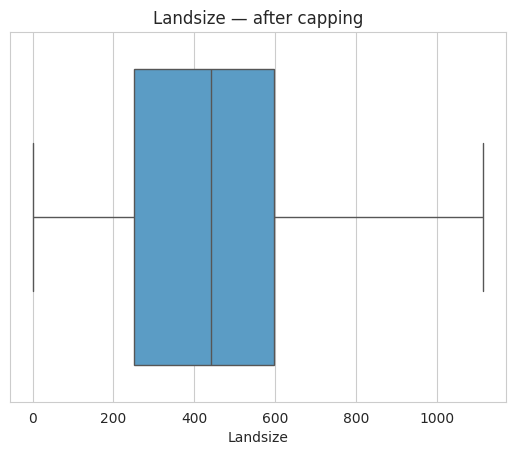

In [24]:
lo, hi = iqr_bounds(df["Landsize"])

# TODO: use .clip() to cap Landsize between lo and hi
df["Landsize"] = df["Landsize"].clip(lower=lo, upper=hi)
# I used .clip() to cap the Landsize values between the lower and upper bounds instead of dropping the rows

sns.boxplot(x=df["Landsize"], color="#49A0D7")
plt.title("Landsize — after capping")
plt.show()


<details>
<summary>Solution</summary>

```python
df["Landsize"] = df["Landsize"].clip(lower=lo, upper=hi)
```
</details>


## 9. Checkpoint Save Your Progress

Save the cleaned dataframe. We'll pick this exact file up in **Activity 2 (Transform & Engineer)**.

In [25]:
df.to_csv("melbourne_clean.csv", index=False)
print("Saved: melbourne_clean.csv —", df.shape)

# Colab only: uncomment to download a local copy to your machine
# from google.colab import files
# files.download("melbourne_clean.csv")


Saved: melbourne_clean.csv — (18395, 19)


---
## Reflection

Before moving to Activity 2, jot down (in the markdown cell below, or out loud with your group):

1. Why did we impute `Landsize` with the **median** rather than the **mean**?
2. `BuildingArea` was 57% missing why didn't we just impute it anyway?
3. Why cap outliers instead of deleting those rows outright?

*(1- Because our data has extreme outliers and the median is safe and doesn't get messed up by them unlike the mean which gets dragged down or up by big numbers

2- Because missing 57% is way too much If we try to fill it we'll just be guessing more than half the data which adds fake info and ruins our analysis

3- Because if we delete every row with an outlier we'll lose other good and useful data in the rest of the columns for those row)*
